In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Day12_Used_Car_Preprocessing_Dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Car_ID,Brand,Year,Mileage_Km,Engine_CC,Power_BHP,Fuel_Type,Transmission,City,Seller_Type,Condition,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
0,CAR0001,Skoda,2021,69708,1152,128.8,Diesel,Manual,Lucknow,Individual,Good,1,0,72,6.38
1,CAR0002,Toyota,2020,88881,903,146.5,Diesel,Automatic,Chandigarh,Individual,Good,1,0,87,4.83
2,CAR0003,Volkswagen,2021,43646,1446,185.9,Diesel,Automatic,Hyderabad,Individual,Very Good,2,0,90,7.30
3,CAR0004,Tata,2019,70847,2069,148.8,Petrol,Manual,Lucknow,Individual,Excellent,3,0,66,3.82
4,CAR0005,Tata,2016,101228,1657,206.0,Petrol,Automatic,Ahmedabad,Dealer,Very Good,2,0,84,1.93


Now, let's get a summary of the DataFrame to check data types and non-null values, and then look at some descriptive statistics.

In [2]:
# Display information about the DataFrame (columns, non-null counts, dtypes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car_ID              320 non-null    object 
 1   Brand               320 non-null    object 
 2   Year                320 non-null    int64  
 3   Mileage_Km          320 non-null    int64  
 4   Engine_CC           320 non-null    int64  
 5   Power_BHP           320 non-null    float64
 6   Fuel_Type           320 non-null    object 
 7   Transmission        320 non-null    object 
 8   City                320 non-null    object 
 9   Seller_Type         320 non-null    object 
 10  Condition           320 non-null    object 
 11  Previous_Owners     320 non-null    int64  
 12  Accidents_Reported  320 non-null    int64  
 13  Service_Score       320 non-null    int64  
 14  Resale_Price_Lakh   320 non-null    float64
dtypes: float64(2), int64(6), object(7)
memory usage: 37.6+ KB

In [3]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,2019.537500,74110.203125,1346.703125,150.489688,1.668750,0.243750,76.203125,4.963031
std,3.341367,38885.260771,543.408160,36.665353,0.865369,0.528164,12.745864,3.359259
min,2014.000000,700.000000,600.000000,51.400000,1.000000,0.000000,55.000000,1.200000
25%,2017.000000,46323.250000,1004.750000,128.450000,1.000000,0.000000,64.750000,2.277500
50%,2020.000000,72718.500000,1303.000000,150.750000,1.000000,0.000000,77.000000,4.610000
75%,2022.000000,97951.500000,1635.250000,171.475000,2.000000,0.000000,87.000000,6.835000
max,2025.000000,320000.000000,5000.000000,390.000000,4.000000,2.000000,98.000000,28.500000


In [4]:
# Drop the 'Car_ID' column as it's an identifier and not a feature.
df = df.drop('Car_ID', axis=1)

display(df.head())

,Brand,Year,Mileage_Km,Engine_CC,Power_BHP,Fuel_Type,Transmission,City,Seller_Type,Condition,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
0,Skoda,2021,69708,1152,128.8,Diesel,Manual,Lucknow,Individual,Good,1,0,72,6.38
1,Toyota,2020,88881,903,146.5,Diesel,Automatic,Chandigarh,Individual,Good,1,0,87,4.83
2,Volkswagen,2021,43646,1446,185.9,Diesel,Automatic,Hyderabad,Individual,Very Good,2,0,90,7.30
3,Tata,2019,70847,2069,148.8,Petrol,Manual,Lucknow,Individual,Excellent,3,0,66,3.82
4,Tata,2016,101228,1657,206.0,Petrol,Automatic,Ahmedabad,Dealer,Very Good,2,0,84,1.93


Now, let's separate the features (X) from the target variable (y), which is `Resale_Price_Lakh`. Then, we'll split the dataset into training and testing sets to ensure our preprocessing steps are applied correctly and to prevent data leakage.

In [5]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Resale_Price_Lakh', axis=1)
y = df['Resale_Price_Lakh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (256, 13)
X_test shape: (64, 13)
y_train shape: (256,)
y_test shape: (64,)


With the data split, we can now proceed with identifying and handling outliers. First, let's identify the numerical columns for which we need to check for outliers. Then, I will visualize the distributions of these numerical features using box plots to better understand their spread and identify potential outliers.

Numerical columns for outlier detection: ['Mileage_Km', 'Engine_CC', 'Power_BHP', 'Previous_Owners', 'Accidents_Reported', 'Service_Score']


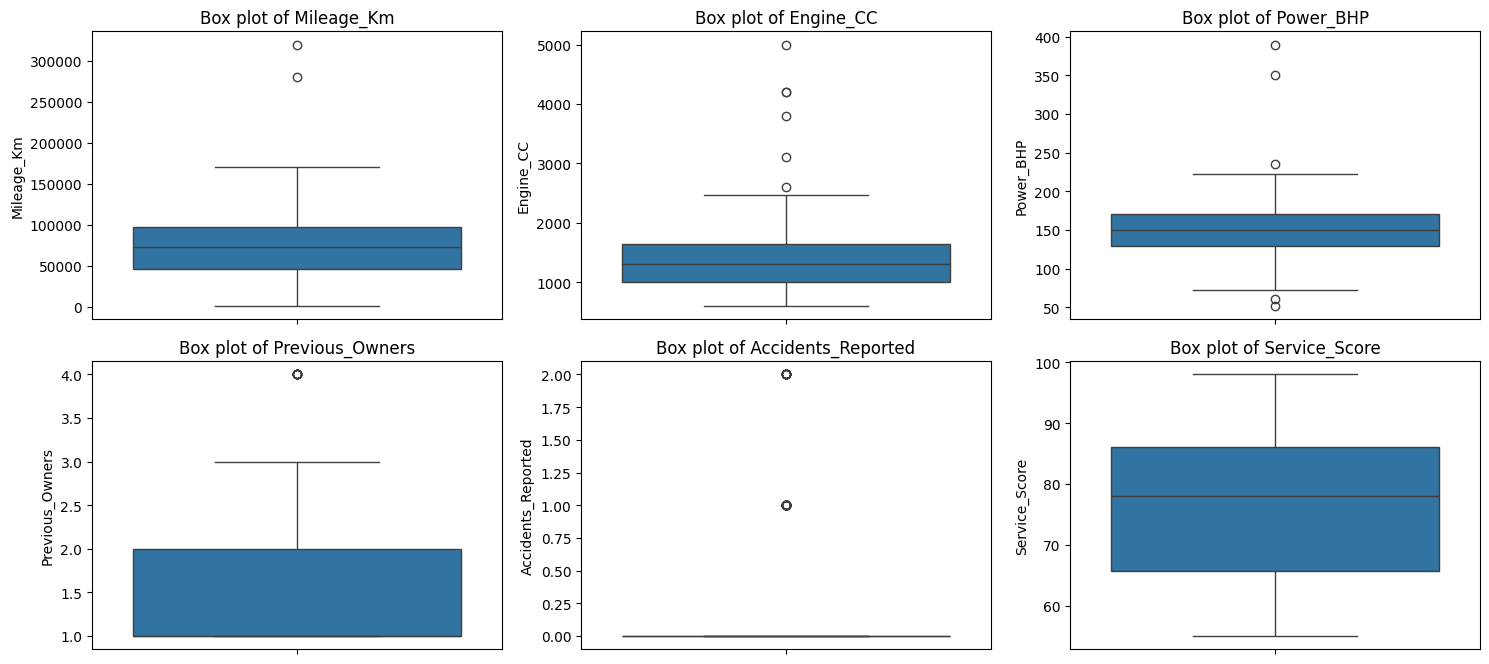

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns (excluding the target variable and 'Year' as it's more categorical in this context)
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 'Year' can be treated as a numerical feature or categorical based on context. For outlier detection, it's less common,
# but let's include it for now to see its distribution if needed. However, typically for car year, values are valid
# unless there are data entry errors. Let's exclude 'Year' for now and focus on other continuous features.
numerical_cols = [col for col in numerical_cols if col not in ['Year']]

print("Numerical columns for outlier detection:", numerical_cols)

# Visualize distributions of numerical features in the training set
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical_cols
    sns.boxplot(y=X_train[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [7]:
# Function to cap outliers using the IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to numerical columns in X_train and X_test
for col in numerical_cols:
    X_train = cap_outliers_iqr(X_train.copy(), col)
    X_test = cap_outliers_iqr(X_test.copy(), col)

print("Outliers capped for numerical columns using IQR method.")

Outliers capped for numerical columns using IQR method.


To verify the effect of outlier capping, let's visualize the distributions of the numerical features again using box plots.

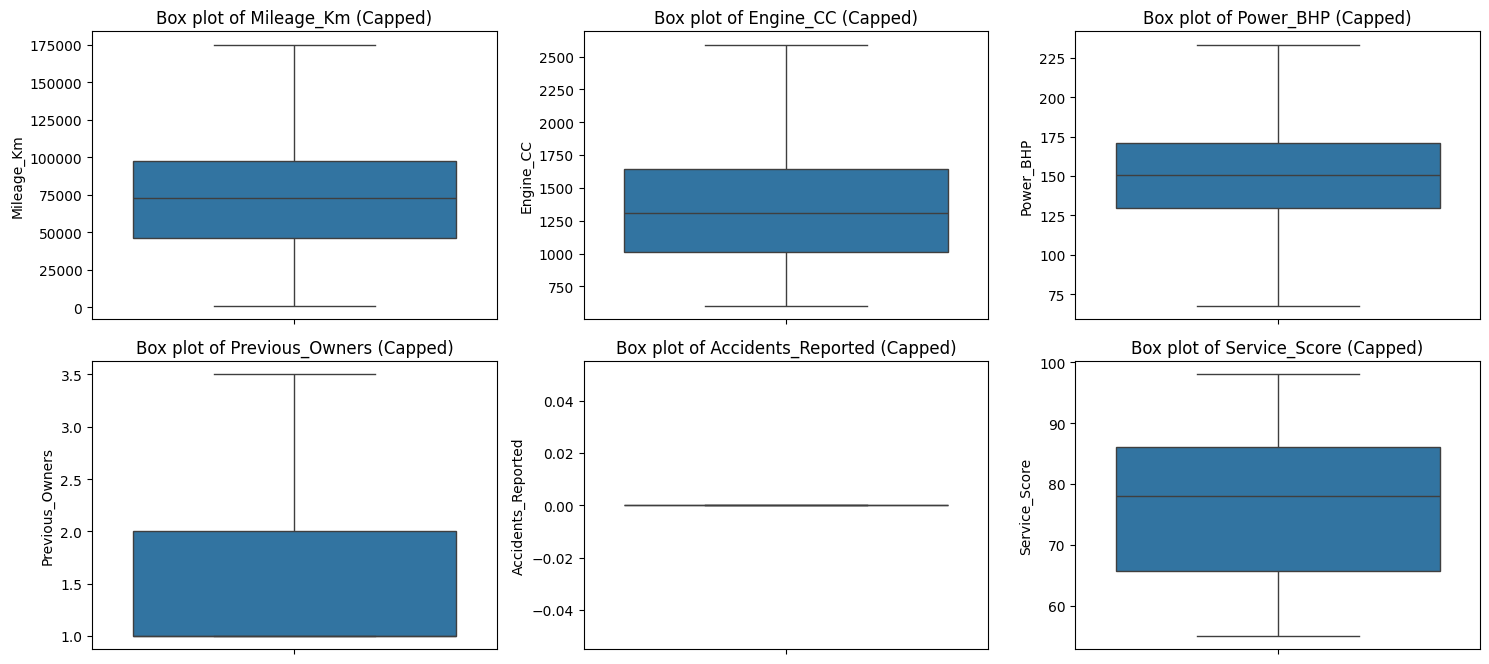

In [8]:
# Visualize distributions of numerical features after outlier capping
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical_cols
    sns.boxplot(y=X_train[col])
    plt.title(f'Box plot of {col} (Capped)')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Separate ordinal and nominal columns
ordinal_cols = ['Condition']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)

# Define the order for the ordinal 'Condition' column
condition_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'] # Assuming this order

# Create a column transformer for preprocessing
# It will apply OrdinalEncoder to 'Condition' and OneHotEncoder to nominal columns
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[condition_order]), ordinal_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough' # Keep numerical columns as they are for now
)

# Fit and transform X_train
X_train_processed = preprocessor.fit_transform(X_train)

# Transform X_test
X_test_processed = preprocessor.transform(X_test)

# Get feature names for processed data
ordinal_feature_names = ordinal_cols
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(nominal_cols)
numerical_feature_names = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude the original numerical columns that were transformed (Year is already excluded for outlier processing but still numerical)
# from numerical_cols if they are not in ordinal_cols or nominal_cols and are not part of the remainder
numerical_feature_names = [col for col in numerical_feature_names if col not in ordinal_cols and col not in nominal_cols]

all_feature_names = list(ordinal_feature_names) + list(onehot_feature_names) + list(numerical_feature_names)

# Convert processed arrays back to DataFrame for easier inspection and further steps
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

display(X_train_processed_df.head())
display(X_test_processed_df.head())

Ordinal columns: ['Condition']
Nominal columns: ['Brand', 'Fuel_Type', 'Transmission', 'City', 'Seller_Type']


,Condition,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mahindra,Brand_Maruti,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,...,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score
132,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2018.0,65330.0,1188.0,159.8,1.0,0.0,71.0
317,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,2022.0,76484.0,1038.0,139.6,1.0,0.0,69.0
234,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2015.0,112800.0,1279.0,163.5,1.0,0.0,70.0
312,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,2023.0,66420.0,1549.0,163.3,2.0,0.0,79.0
232,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,2016.0,98325.0,1687.0,136.2,2.0,0.0,78.0


,Condition,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mahindra,Brand_Maruti,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,...,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score
167,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,2018.0,105462.0,600.0,119.1,1.0,0.0,72.0
230,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,2024.0,40524.0,1686.0,142.9,2.0,0.0,60.0
25,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,2016.0,98454.0,697.0,127.5,1.0,0.0,96.0
63,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,2018.0,103984.0,600.0,125.4,2.0,0.0,90.0
9,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2015.0,149183.0,1332.0,153.3,1.0,0.0,67.0


With categorical variables encoded, the next crucial step is feature scaling. I will apply Min-Max scaling to the numerical features to bring them to a similar range, which often improves the performance of many machine learning algorithms. This will be done using `MinMaxScaler` and, importantly, fitted only on the training data and then applied to both training and test sets to prevent data leakage.

In [10]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns for scaling after encoding (these are the 'remainder' columns from the preprocessor)
# These are the columns that were not affected by OrdinalEncoder or OneHotEncoder in the previous step.
# We need to make sure we select the correct columns from the processed DataFrames.
# The 'all_feature_names' created earlier correctly separates these, let's confirm.

# Select only the true numerical columns that need scaling from the processed DataFrame
# The numerical columns from the original X_train were 'Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP', 'Previous_Owners', 'Accidents_Reported', 'Service_Score'
# From these, 'Year' was explicitly excluded from outlier detection for a specific reason (context).
# Let's consider all numerical columns that weren't encoded.

# The `numerical_feature_names` already contains the original numerical columns.
# Let's verify that these are the ones still present and numerical in `X_train_processed_df`.

scaled_numerical_cols = [col for col in numerical_feature_names if col in X_train_processed_df.columns]

print("Numerical columns to be scaled:", scaled_numerical_cols)

scaler = MinMaxScaler()

# Fit the scaler on the training data's numerical columns and transform both train and test sets
X_train_processed_df[scaled_numerical_cols] = scaler.fit_transform(X_train_processed_df[scaled_numerical_cols])
X_test_processed_df[scaled_numerical_cols] = scaler.transform(X_test_processed_df[scaled_numerical_cols])

print("Features scaled using Min-Max Scaling.")

display(X_train_processed_df.head())
display(X_test_processed_df.head())

Numerical columns to be scaled: ['Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP', 'Previous_Owners', 'Accidents_Reported', 'Service_Score']
Features scaled using Min-Max Scaling.


,Condition,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mahindra,Brand_Maruti,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,...,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score
132,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.363636,0.369811,0.295181,0.556585,0.0,0.0,0.372093
317,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.727273,0.433832,0.219880,0.434825,0.0,0.0,0.325581
234,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.090909,0.642276,0.340863,0.578888,0.0,0.0,0.348837
312,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.818182,0.376067,0.476406,0.577682,0.4,0.0,0.558140
232,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.181818,0.559193,0.545683,0.414331,0.4,0.0,0.534884


,Condition,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mahindra,Brand_Maruti,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,...,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score
167,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.363636,0.600158,0.000000,0.311257,0.0,0.0,0.395349
230,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.909091,0.227431,0.545181,0.454717,0.4,0.0,0.116279
25,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.181818,0.559934,0.048695,0.361890,0.0,0.0,0.953488
63,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.363636,0.591674,0.000000,0.349231,0.4,0.0,0.813953
9,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.090909,0.851104,0.367470,0.517405,0.0,0.0,0.279070


We have now completed the data preprocessing steps: dropping irrelevant columns, splitting data, handling outliers, encoding categorical variables, and scaling numerical features. Let's verify the final preprocessed datasets (`X_train_processed_df`, `X_test_processed_df`, `y_train`, `y_test`) by checking their shapes and displaying the head of the feature DataFrames to ensure all transformations have been applied correctly.

In [11]:
print("Final Preprocessed Datasets Shapes:")
print(f"X_train_processed_df shape: {X_train_processed_df.shape}")
print(f"X_test_processed_df shape: {X_test_processed_df.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nHead of X_train_processed_df:")
display(X_train_processed_df.head())

print("\nHead of X_test_processed_df:")
display(X_test_processed_df.head())

print("\nHead of y_train:")
display(y_train.head())

print("\nHead of y_test:")
display(y_test.head())

Final Preprocessed Datasets Shapes:
X_train_processed_df shape: (256, 37)
X_test_processed_df shape: (64, 37)
y_train shape: (256,)
y_test shape: (64,)

Head of X_train_processed_df:


,Condition,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mahindra,Brand_Maruti,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,...,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score
132,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.363636,0.369811,0.295181,0.556585,0.0,0.0,0.372093
317,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.727273,0.433832,0.219880,0.434825,0.0,0.0,0.325581
234,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.090909,0.642276,0.340863,0.578888,0.0,0.0,0.348837
312,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.818182,0.376067,0.476406,0.577682,0.4,0.0,0.558140
232,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.181818,0.559193,0.545683,0.414331,0.4,0.0,0.534884



Head of X_test_processed_df:


,Condition,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mahindra,Brand_Maruti,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,...,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score
167,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.363636,0.600158,0.000000,0.311257,0.0,0.0,0.395349
230,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.909091,0.227431,0.545181,0.454717,0.4,0.0,0.116279
25,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.181818,0.559934,0.048695,0.361890,0.0,0.0,0.953488
63,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.363636,0.591674,0.000000,0.349231,0.4,0.0,0.813953
9,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.090909,0.851104,0.367470,0.517405,0.0,0.0,0.279070



Head of y_train:


,Resale_Price_Lakh
132,4.26
317,5.30
234,1.23
312,7.09
232,2.69



Head of y_test:


,Resale_Price_Lakh
167,1.62
230,8.35
25,2.11
63,2.82
9,1.20
